[Previous: Architecture 1: Monolith and Modular Monolith](01_Monolith_and_Modular_Monolith.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: Architecture 3: Microservices](03_Microservices.ipynb)

# Architecture 2: Layered, Hexagonal and MVC

Inside a module or a service, the arrows still need rules. This module covers the three arrangements you will meet most often.

**Learning objectives.** After this module you can:

* build a layered application and enforce that dependencies point one way;
* explain ports and adapters (hexagonal architecture) and test a core with no database;
* implement MVC with the Observer pattern and trace the update loop.

## 1. Layered architecture

**Idea.** Stack the code in layers with a single rule: a layer may call the layer directly below it, never above, never skipping.
The classic three are **presentation** (HTTP handlers, CLI), **domain / service** (the rules), and **data** (repositories that talk to storage).

The payoff is replaceability: swap the web framework or the database without touching the rules. The cost is boilerplate when a feature is trivial.

(201, {'id': 1, 'items': {'lamp': 25}, 'total': 25})
(400, {'error': 'empty order'})
violations: []


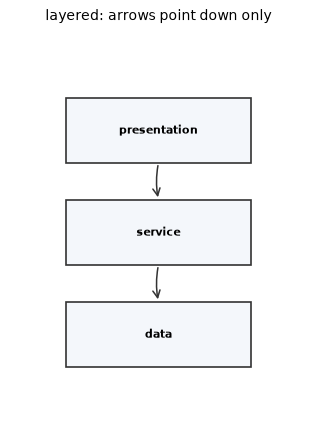

In [1]:
from dplab import component_diagram, check_dependencies, class_diagram, traced, trace

# data layer
class OrderRepository:
    def __init__(self): self.rows = {}
    def save(self, order):   self.rows[order["id"]] = order
    def get(self, order_id): return self.rows.get(order_id)

# service layer: the rules, depends only on the data layer
class OrderService:
    def __init__(self, repo): self.repo = repo
    def place(self, order_id, items):
        if not items:
            raise ValueError("empty order")
        order = {"id": order_id, "items": items, "total": sum(items.values())}
        self.repo.save(order)
        return order

# presentation layer: translates requests to service calls
class OrderController:
    def __init__(self, service): self.service = service
    def post_order(self, request):
        try:
            order = self.service.place(request["id"], request["items"])
            return 201, order
        except ValueError as e:
            return 400, {"error": str(e)}

controller = OrderController(OrderService(OrderRepository()))
print(controller.post_order({"id": 1, "items": {"lamp": 25}}))
print(controller.post_order({"id": 2, "items": {}}))

deps = {"presentation": {"service"}, "service": {"data"}, "data": set()}
allowed = {"presentation": {"service"}, "service": {"data"}, "data": set()}
print("violations:", check_dependencies(deps, allowed))
component_diagram(["presentation", "service", "data"], [("presentation", "service"), ("service", "data")],
                  layout={"presentation": (0, 0), "service": (0, 1), "data": (0, 2)}, title="layered: arrows point down only")

## 2. Hexagonal architecture (ports and adapters)

**Idea.** Layers still let the domain depend on the database layer. Hexagonal turns that arrow around: the **core** defines the interfaces it needs (**ports**),
and the outside world plugs in **adapters** that implement them. Databases, web frameworks and message queues all live at the edge.

The concrete payoff: the core can be tested with an in-memory adapter, with no database, in milliseconds. The same core runs in production with the SQL adapter.

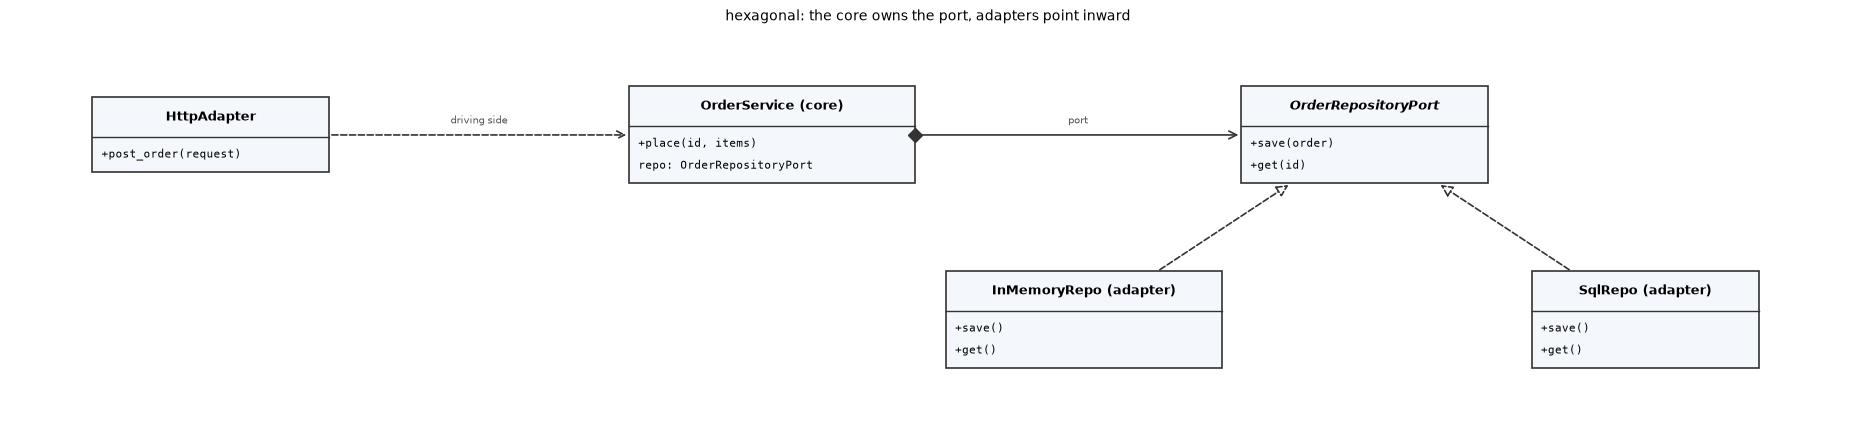

In [2]:
class_diagram(
    {"OrderService (core)": ["+place(id, items)", "repo: OrderRepositoryPort"], "OrderRepositoryPort": ["+save(order)", "+get(id)"],
     "InMemoryRepo (adapter)": ["+save()", "+get()"], "SqlRepo (adapter)": ["+save()", "+get()"], "HttpAdapter": ["+post_order(request)"]},
    [("InMemoryRepo (adapter)", "OrderRepositoryPort", "implements"), ("SqlRepo (adapter)", "OrderRepositoryPort", "implements"),
     ("OrderService (core)", "OrderRepositoryPort", "has", "port"), ("HttpAdapter", "OrderService (core)", "uses", "driving side")],
    abstract={"OrderRepositoryPort"},
    layout={"HttpAdapter": (-1.6, 0), "OrderService (core)": (0.2, 0), "OrderRepositoryPort": (2.1, 0), "InMemoryRepo (adapter)": (1.2, 1), "SqlRepo (adapter)": (3.0, 1)},
    title="hexagonal: the core owns the port, adapters point inward")

core tests pass with the in-memory adapter


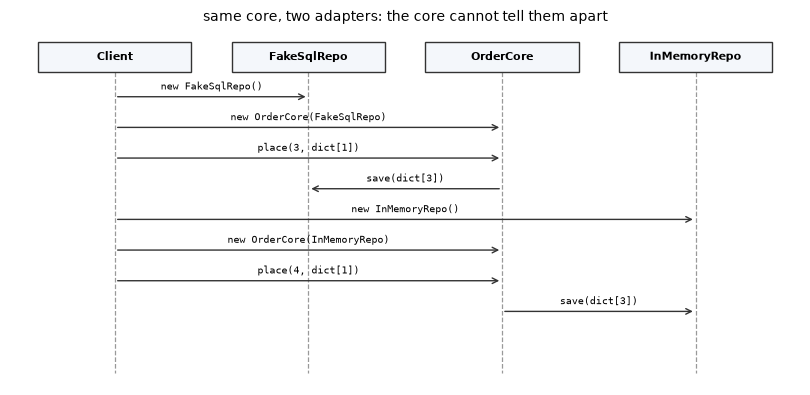

In [3]:
from typing import Protocol

class OrderRepositoryPort(Protocol):              # defined by the core
    def save(self, order) -> None: ...
    def get(self, order_id): ...

@traced
class InMemoryRepo:                               # adapter for tests
    def __init__(self): self.rows = {}
    def save(self, order): self.rows[order["id"]] = order
    def get(self, order_id): return self.rows.get(order_id)

@traced
class FakeSqlRepo:                                # adapter for production (simulated)
    def __init__(self): self.statements = []
    def save(self, order): self.statements.append(f"INSERT INTO orders VALUES ({order['id']}, {order['total']})")
    def get(self, order_id): self.statements.append(f"SELECT * FROM orders WHERE id = {order_id}"); return None

@traced
class OrderCore:
    def __init__(self, repo: OrderRepositoryPort): self.repo = repo
    def place(self, order_id, items):
        if not items: raise ValueError("empty order")
        order = {"id": order_id, "items": items, "total": sum(items.values())}
        self.repo.save(order)
        return order

# The test: no database anywhere
def test_place_rejects_empty():
    core = OrderCore(InMemoryRepo())
    try:
        core.place(1, {}); assert False
    except ValueError:
        pass
    assert core.place(2, {"lamp": 25})["total"] == 25
test_place_rejects_empty(); print("core tests pass with the in-memory adapter")

with trace() as t:
    OrderCore(FakeSqlRepo()).place(3, {"chair": 80})
    OrderCore(InMemoryRepo()).place(4, {"chair": 80})
t.diagram(title="same core, two adapters: the core cannot tell them apart")

> **What to notice.** `OrderCore` never imports a database module. The arrow from the SQL adapter points *into* the core's port, the reverse of the layered picture.

## 3. MVC: Observer applied to user interfaces

**Idea.** The **model** holds state and notifies observers when it changes. **Views** render the model and subscribe to it. The **controller** turns user input into model updates.
Views never write to the model directly, and the model knows nothing about views. It is the Observer pattern with names for the roles.

  [text view] count = 1
  [bar view]  #
  [text view] count = 6
  [bar view]  ######


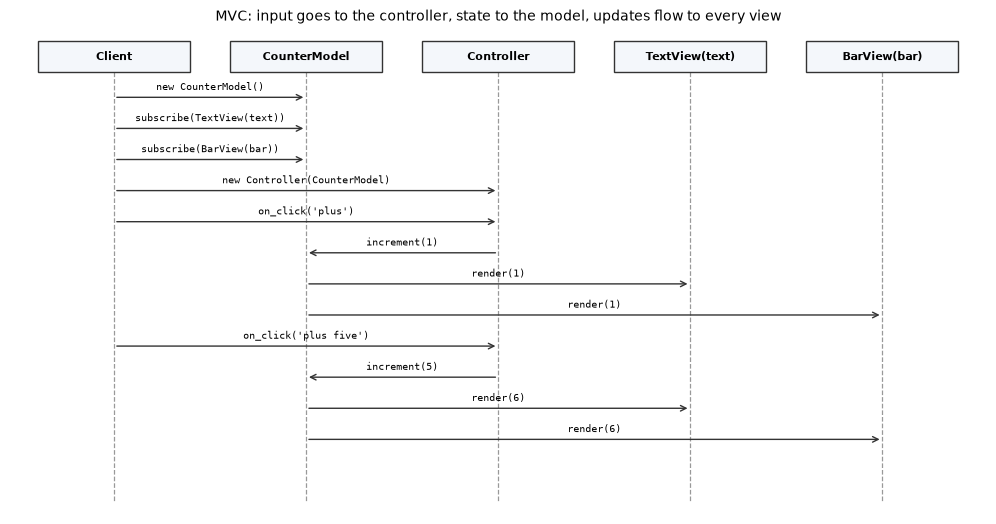

In [4]:
@traced
class CounterModel:
    def __init__(self): self.value, self.views = 0, []
    def subscribe(self, view): self.views.append(view)
    def increment(self, by):
        self.value += by
        for v in self.views: v.render(self.value)

@traced
class TextView:
    name = "text"
    def render(self, value): print(f"  [text view] count = {value}")

@traced
class BarView:
    name = "bar"
    def render(self, value): print(f"  [bar view]  {'#' * value}")

@traced
class Controller:
    def __init__(self, model): self.model = model
    def on_click(self, button):
        self.model.increment(1 if button == "plus" else 5)

with trace() as t:
    model = CounterModel()
    model.subscribe(TextView()); model.subscribe(BarView())
    ctl = Controller(model)
    ctl.on_click("plus"); ctl.on_click("plus five")
t.diagram(title="MVC: input goes to the controller, state to the model, updates flow to every view")

## Try it yourself

**Exercise 1.** Add a `NotificationPort` to the hexagonal core (`notify(user, text)`) with a console adapter and a silent test adapter. Keep the core free of prints.

**Exercise 2.** Write a layered violation on purpose (the data layer calling the controller) and show that `check_dependencies` catches it.

**Exercise 3.** Add a third MVC view that only renders when the value is a multiple of 5. Does the model need to change?

**Exercise 4 (challenge).** Replace `FakeSqlRepo` with a real `sqlite3` adapter (in-memory database) and run the same core test against both adapters.

<details><summary>Solutions</summary>

```python
# Exercise 1
class ConsoleNotifier:
    def notify(self, user, text): print(f"to {user}: {text}")
class SilentNotifier:
    def __init__(self): self.sent = []
    def notify(self, user, text): self.sent.append((user, text))
# OrderCore.__init__(self, repo, notifier) and call self.notifier.notify(...) after save.

# Exercise 2
print(check_dependencies({"data": {"presentation"}}, allowed))   # [('data', 'presentation')]

# Exercise 3: no. The view filters inside render(); the model still notifies everyone.

# Exercise 4
import sqlite3
class SqliteRepo:
    def __init__(self):
        self.db = sqlite3.connect(":memory:"); self.db.execute("CREATE TABLE orders(id INTEGER PRIMARY KEY, total REAL)")
    def save(self, order): self.db.execute("INSERT INTO orders VALUES (?, ?)", (order["id"], order["total"]))
    def get(self, order_id): return self.db.execute("SELECT id, total FROM orders WHERE id = ?", (order_id,)).fetchone()
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [5]:
from dplab import quiz

quiz('arch2')

Checkpoint quiz, Architecture 2 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. In a layered architecture, dependencies point
    a) in any direction
    b) downward only: UI to service to data
    c) upward only
    d) sideways

Q2. In hexagonal architecture a 'port' is
    a) a network socket
    b) an interface the core defines and adapters implement
    c) a database table
    d) a UI screen

Q3. The practical payoff of ports and adapters is
    a) fewer files
    b) the core logic is testable without databases or web frameworks
    c) faster network calls
    d) no need for interfaces

Q4. In MVC the view refreshes when
    a) the user asks
    b) the model changes and notifies it
    c) the controller is created
    d) the server restarts


## Key takeaways

* Layered: presentation, service, data; arrows point down; the checker from Module 1 enforces it.
* Hexagonal: the core defines ports, adapters implement them, so the core is testable in memory and the database is a plug-in.
* MVC is Observer with roles: model notifies, views render, controllers translate input.

**Next:** what changes when the parts run in different processes. [Architecture 3](03_Microservices.ipynb).

[Previous: Architecture 1: Monolith and Modular Monolith](01_Monolith_and_Modular_Monolith.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: Architecture 3: Microservices](03_Microservices.ipynb)